# Task 3: Evaluation Metrics Analysis

## Metrics Implemented

1. Progress-Based Score - How much of the string was reduced 
2. Valid Steps Ratio - What % of attempted steps were valid 
3. **Composite Multi-Metric Score** - Weighted combination 

## Goals
- Analyze how different metrics score real LLM outputs
- Compare metrics across models and prompting techniques
- Test edge cases to validate metric robustness
- Determine which metric works best in which scenario


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for imports
import sys
sys.path.insert(0, str(Path('..').resolve()))

from llm_evaluation.metrics_advanced import (
    evaluate_all_results, 
    analyze_edge_cases, 
    format_example,
    load_all_data,
    simulate_solution,
    calculate_progress_score,
    calculate_valid_steps_ratio,
    calculate_composite_score
)

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Color schemes
MODEL_COLORS = {
    'llama-3.3-70b-versatile': '#3498db',
    'meta-llama/llama-4-scout-17b-16e-instruct': '#e74c3c',
    'llama-3.1-8b-instant': '#2ecc71',
}

MODEL_NAMES = {
    'llama-3.3-70b-versatile': 'LLaMA 3.3 70B',
    'meta-llama/llama-4-scout-17b-16e-instruct': 'LLaMA 4 Scout',
    'llama-3.1-8b-instant': 'LLaMA 3.1 8B',
}

PROMPT_NAMES = {
    'zero_shot': 'Zero-Shot',
    'few_shot': 'Few-Shot',
    'cot': 'CoT',
    'self_verify': 'Self-Verify',
    'role_classify': 'Role-Classify',
}

print("Setup complete!")


Setup complete!


In [3]:
# Evaluate all results
base_path = Path('..').resolve()
all_metrics = evaluate_all_results(base_path)
puzzles, solutions, metadata = load_all_data(base_path)

print(f"📊 Evaluated {len(all_metrics)} LLM outputs")

# Convert to DataFrame for analysis
df = pd.DataFrame([{
    'problem_id': m.problem_id,
    'model': MODEL_NAMES.get(m.model, m.model),
    'prompt_type': PROMPT_NAMES.get(m.prompt_type, m.prompt_type),
    'difficulty': m.difficulty,
    'generator': m.generator,
    'is_correct': m.is_correct,
    'binary_accuracy': 1.0 if m.is_correct else 0.0,
    'progress_score': m.progress_score,
    'valid_steps_ratio': m.valid_steps_ratio,
    'composite_score': m.composite_score,
    'initial_length': m.initial_length,
    'final_length': m.final_length,
    'valid_steps': m.valid_steps,
    'total_steps': m.total_steps,
    'solution_length': len(m.parsed_solution),
    'optimal_length': len(m.ground_truth),
} for m in all_metrics])

print(f"\n📋 DataFrame shape: {df.shape}")
df.head()


📊 Evaluated 480 LLM outputs

📋 DataFrame shape: (480, 16)


,problem_id,model,prompt_type,difficulty,generator,is_correct,binary_accuracy,progress_score,valid_steps_ratio,composite_score,initial_length,final_length,valid_steps,total_steps,solution_length,optimal_length
0,000,LLaMA 3.1 8B,Role-Classify,medium,backward_5,True,1.0,1.000000,1.000000,1.000000,16,0,5,5,5,5
1,001,LLaMA 3.1 8B,Role-Classify,medium,backward_5,False,0.0,0.166667,0.333333,0.091667,18,15,1,3,3,5
2,002,LLaMA 3.1 8B,Role-Classify,medium,backward_5,False,0.0,0.636364,0.750000,0.271591,11,4,3,4,4,5
3,005,LLaMA 3.1 8B,Role-Classify,medium,backward_5,True,1.0,1.000000,0.086207,0.771552,16,0,5,58,58,5
4,010,LLaMA 3.1 8B,Role-Classify,hard,backward_7,False,0.0,0.937500,0.093333,0.248375,16,1,7,75,75,7


In [4]:
# Summary statistics for all metrics
print("="*80)
print("METRICS SUMMARY STATISTICS")
print("="*80)

metrics_to_compare = ['binary_accuracy', 'progress_score', 'valid_steps_ratio', 'composite_score']
stats_df = df[metrics_to_compare].describe().round(3)
print(stats_df)

print("\n" + "="*80)
print("CORRELATION BETWEEN METRICS")
print("="*80)
corr = df[metrics_to_compare].corr().round(3)
print(corr)


METRICS SUMMARY STATISTICS
       binary_accuracy  progress_score  valid_steps_ratio  composite_score
count          480.000         480.000            480.000          480.000
mean             0.508           0.712              0.710            0.576
std              0.500           0.390              0.320            0.380
min              0.000           0.000              0.000            0.000
25%              0.000           0.510              0.500            0.237
50%              1.000           1.000              0.778            0.764
75%              1.000           1.000              1.000            1.000
max              1.000           1.000              1.000            1.000

CORRELATION BETWEEN METRICS
                   binary_accuracy  progress_score  valid_steps_ratio  \
binary_accuracy              1.000           0.753              0.111   
progress_score               0.753           1.000              0.286   
valid_steps_ratio            0.111           0.286

High syntactic validity and apparent progress even in incorrect trajectories, with near-zero correlation between valid step execution and task success, indicating that commonly used intermediate metrics fail to identify genuine reasoning competence.

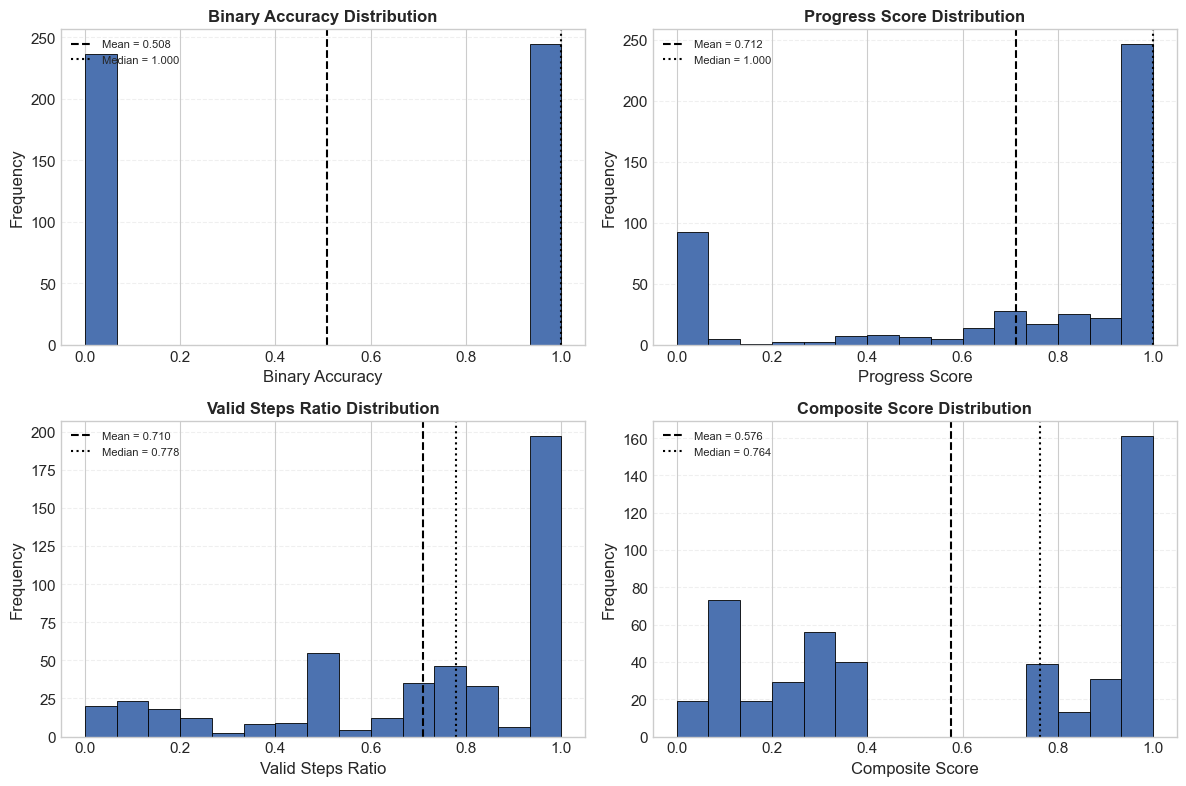

In [18]:
import matplotlib.pyplot as plt

# -----------------------------
# Metric distribution plots
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metric_info = [
    ('binary_accuracy', 'Binary Accuracy'),
    ('progress_score', 'Progress Score'),
    ('valid_steps_ratio', 'Valid Steps Ratio'),
    ('composite_score', 'Composite Score'),
]

for ax, (metric, title) in zip(axes.flatten(), metric_info):
    values = df[metric]

    # Histogram
    ax.hist(
        values,
        bins=15,
        color='#4C72B0',      # muted blue
        edgecolor='black',
        linewidth=0.6
    )

    # Mean and median
    ax.axvline(
        values.mean(),
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f"Mean = {values.mean():.3f}"
    )
    ax.axvline(
        values.median(),
        color='black',
        linestyle=':',
        linewidth=1.5,
        label=f"Median = {values.median():.3f}"
    )

    ax.set_title(f"{title} Distribution", fontsize=12)
    ax.set_xlabel(title)
    ax.set_ylabel("Frequency")
    ax.set_xlim(-0.05, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig(
    "../results/metrics_distributions.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


## Comparing Metrics Across Models


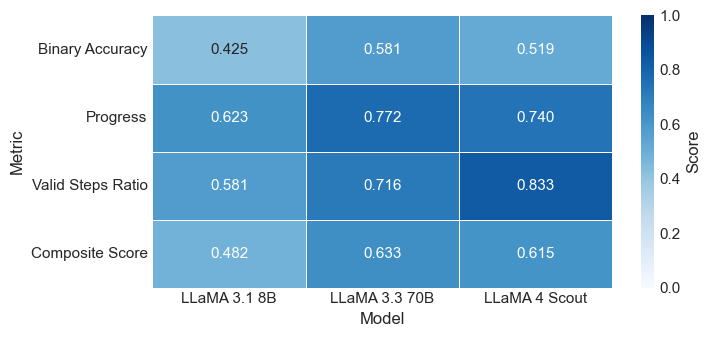


Model Comparison Table:
               Binary Accuracy  Progress  Valid Steps Ratio  Composite Score
model                                                                       
LLaMA 3.1 8B             0.425     0.623              0.581            0.482
LLaMA 3.3 70B            0.581     0.772              0.716            0.633
LLaMA 4 Scout            0.519     0.740              0.833            0.615


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate metrics
model_metrics = df.groupby('model')[metrics_to_compare].mean().round(3)

# Rename metrics for display
metric_labels = {
    'binary_accuracy': 'Binary Accuracy',
    'progress_score': 'Progress',
    'valid_steps_ratio': 'Valid Steps Ratio',
    'composite_score': 'Composite Score'
}

model_metrics = model_metrics.rename(columns=metric_labels)

# -----------------------------
# Single heatmap (minimal)
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 3.5))

sns.heatmap(
    model_metrics.T,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Score'},
    ax=ax
)

# ax.set_title("Evaluation Metrics by Model", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Metric")

plt.tight_layout()
plt.savefig(
    "../results/metrics_by_model.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# -----------------------------
# Table (textual, exact)
# -----------------------------
print("\nModel Comparison Table:")
print(model_metrics.to_string())


### Evaluation Metrics Across Prompting Techniques

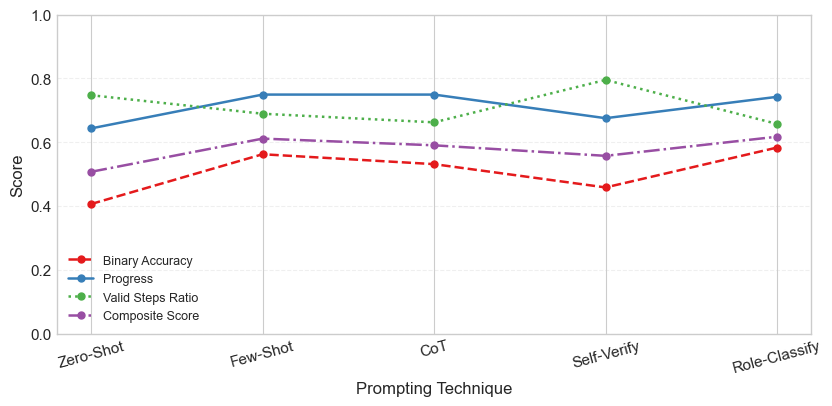


Prompt Type Comparison Table:
               Binary Accuracy  Progress  Valid Steps Ratio  Composite Score
prompt_type                                                                 
Zero-Shot                0.406     0.643              0.747            0.507
Few-Shot                 0.562     0.749              0.689            0.611
CoT                      0.531     0.749              0.662            0.590
Self-Verify              0.458     0.675              0.795            0.557
Role-Classify            0.583     0.742              0.657            0.617


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Order
prompt_order = ['Zero-Shot', 'Few-Shot', 'CoT', 'Self-Verify', 'Role-Classify']

# Aggregate metrics
prompt_metrics = (
    df.groupby('prompt_type')[metrics_to_compare]
      .mean()
      .reindex(prompt_order)
      .round(3)
)

# Display labels
metric_labels = {
    'binary_accuracy': 'Binary Accuracy',
    'progress_score': 'Progress',
    'valid_steps_ratio': 'Valid Steps Ratio',
    'composite_score': 'Composite Score'
}

# Classic, print-safe line styles
LINE_STYLES = {
    'binary_accuracy': ('#e41a1c', '--'),   # red
    'progress_score': ('#377eb8', '-'),    # blue
    'valid_steps_ratio': ('#4daf4a', ':'), # green
    'composite_score': ('#984ea3', '-.')   # purple
}


# -----------------------------
# Line plot only
# -----------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.2))

for metric in metrics_to_compare:
    color, style = LINE_STYLES[metric]
    ax.plot(
        prompt_metrics.index,
        prompt_metrics[metric],
        marker='o',
        markersize=5,
        linewidth=1.8,
        linestyle=style,
        color=color,
        label=metric_labels[metric]
    )

# ax.set_title("Evaluation Metrics Across Prompting Techniques", fontsize=13)
ax.set_xlabel("Prompting Technique")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(
    "../results/metrics_by_prompt.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# -----------------------------
# Table (exact values)
# -----------------------------
print("\nPrompt Type Comparison Table:")
print(prompt_metrics.rename(columns=metric_labels).to_string())


### How Metrics Behave in Different Scenarios


### What the Metrics Actually Capture?

To understand *how* different evaluation metrics behave beyond simple correctness,
we categorize model outputs into interpretable edge cases based on semantic progress
and syntactic validity.

### Edge Case Categories (Counts)
- **Correct Optimal / Correct Longer**: Semantically correct solutions (optimal or redundant)
- **Almost There / Good Progress**: Near-complete semantic progress but incorrect final state
- **All Valid Wrong**: All steps valid, but semantically incorrect outcome
- **Minimal Progress / Mostly Invalid**: Weak semantic progress and/or invalid actions
- **Zero Steps**: Degenerate failure modes

### Metric Behavior Across Edge Cases

| Edge Case          | Binary Acc | Progress | Valid Steps | Composite |
|--------------------|------------|----------|-------------|-----------|
| Correct Optimal    | ✓          | ✓✓✓      | ✓✓✓         | ✓✓✓       |
| Correct Longer     | ✓          | ✓✓✓      | ✗           | ✓✓        |
| Almost There       | ✗          | ✓✓✓      | ✗           | ✓         |
| All Valid Wrong    | ✗          | ✓✓       | ✓✓✓         | ✓         |
| Minimal Progress   | ✗          | ✗        | ✓           | ✗         |
| Mostly Invalid     | ✗          | ✗        | ✗           | ✗         |

### Insights

1. **Binary accuracy fails to distinguish near-miss reasoning from total failure**  
   Almost-there solutions (≈94% progress) are indistinguishable from zero-progress cases.

2. **Valid-steps ratio is insufficient as a reasoning metric**  
   The *all-valid-wrong* category achieves perfect validity despite semantic failure.

3. **Composite score provides the cleanest separation of reasoning regimes**  
   It assigns:
   - high scores to correct and near-correct solutions,
   - intermediate scores to valid-but-wrong reasoning,
   - low scores to weak or invalid attempts.

Overall, this analysis demonstrates that **semantic progress and syntactic validity
must be jointly evaluated** to meaningfully characterize LLM reasoning behavior.


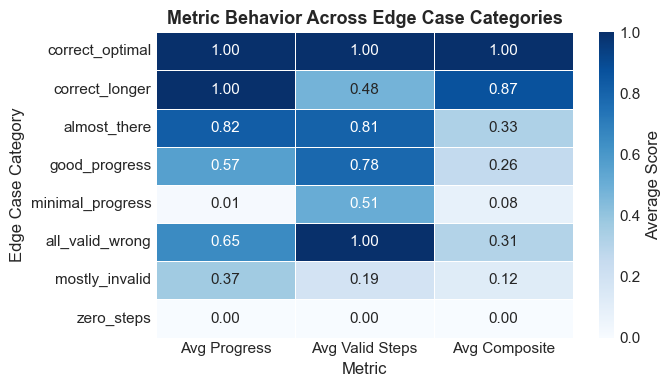

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build dataframe
edge_df = pd.DataFrame(edge_summary)
edge_df = edge_df[edge_df['Count'] > 0]

heatmap_data = edge_df.set_index('Category')[
    ['Avg Progress', 'Avg Valid Steps', 'Avg Composite']
]

fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Average Score'},
    ax=ax
)

ax.set_title("Metric Behavior Across Edge Case Categories", fontsize=13)
ax.set_xlabel("Metric")
ax.set_ylabel("Edge Case Category")

plt.tight_layout()
plt.savefig("../results/edge_case_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Metric Relationships: Scatter Plot Analysis


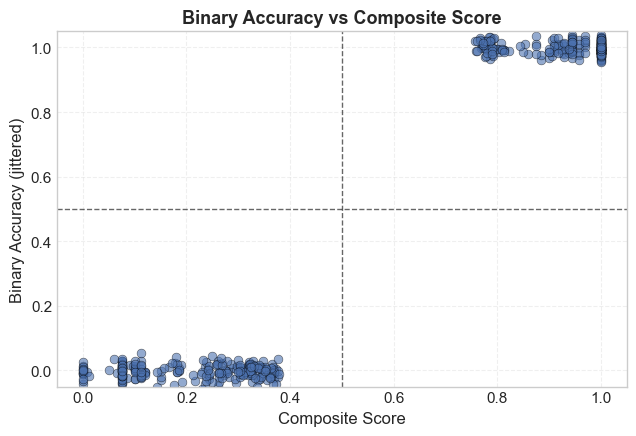

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Jitter binary accuracy for visibility
binary_jitter = df['binary_accuracy'] + np.random.normal(0, 0.02, len(df))

fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Scatter
ax.scatter(
    df['composite_score'],
    binary_jitter,
    s=40,
    alpha=0.6,
    color='#4C72B0',
    edgecolor='black',
    linewidth=0.4
)

# Reference lines
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel("Composite Score")
ax.set_ylabel("Binary Accuracy (jittered)")
ax.set_title("Binary Accuracy vs Composite Score", fontsize=13)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(axis='both', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    "../results/composite_vs_binary.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


Figure - contrasts binary accuracy with the composite score.
While binary accuracy is strictly bimodal, the composite score assigns
continuous values to incorrect solutions based on semantic progress and
step validity.


This demonstrates that binary accuracy alone is insufficient for evaluating
reasoning behavior, and motivates the use of composite metrics that capture
graded progress.

## Metric Comparison: Strengths and Weaknesses

Different evaluation metrics capture distinct aspects of model behavior.  
The table below summarizes their respective strengths, limitations, and appropriate use cases.

| Metric | Strengths | Limitations | Best Use Case |
|------|----------|-------------|---------------|
| **Binary Accuracy** | • Clear and interpretable (0/1)<br>• Exact measure of task completion | • No partial credit<br>• Cannot distinguish near-misses from total failures | Final task completion rate, headline results |
| **Progress Score** | • Captures how close the model gets<br>• Provides graded signal for failures<br>• Smooth (non-bimodal) distribution | • Can reward random deletions<br>• Ignores validity of actions | Analyzing failed attempts, training feedback |
| **Valid Steps Ratio** | • Measures rule compliance<br>• Identifies syntactic understanding | • High validity ≠ semantic progress<br>• Can be misleading when used alone | Diagnosing syntax vs. semantic reasoning |
| **Composite Score** | • Integrates correctness, progress, and validity<br>• Smooth gradient for optimization | • Requires weight tuning<br>• Less directly interpretable | Overall model ranking, hyperparameter tuning |

### Discriminative Power Across Models

To assess how well each metric differentiates between models, we measure **variance across model-level means**.

- Metrics with **higher variance** provide stronger separation between models.
- Metrics with **low variance** tend to collapse model differences.
  
> Binary accuracy often shows limited variance due to its coarse, bimodal nature,  
> while composite and progress-based metrics exhibit higher variability, enabling finer-grained model comparison.


In [27]:
print("DISCRIMINATIVE POWER: Standard Deviation Across Models")

for metric in metrics_to_compare:
    model_means = df.groupby('model')[metric].mean()
    std_across_models = model_means.std()
    range_across_models = model_means.max() - model_means.min()
    print(f"{metric:20s}: σ={std_across_models:.4f}, range={range_across_models:.4f}")


DISCRIMINATIVE POWER: Standard Deviation Across Models
binary_accuracy     : σ=0.0786, range=0.1563
progress_score      : σ=0.0785, range=0.1494
valid_steps_ratio   : σ=0.1258, range=0.2514
composite_score     : σ=0.0826, range=0.1512


## Metric Selection by Evaluation Scenario

Different evaluation scenarios require different metrics.  
No single metric is universally optimal; each captures a distinct aspect of model behavior.

| Scenario | Recommended Metrics | Rationale |
|--------|---------------------|-----------|
| **Model Comparison for Deployment** | Binary Accuracy + Composite Score | Binary accuracy reports task completion rate, while composite score helps differentiate models with similar accuracy by accounting for partial progress and validity. |
| **Failure Analysis / Debugging** | Progress Score + Valid Steps Ratio | Distinguishes semantic failure from syntactic failure. High validity with low progress indicates rule-following without goal-directed reasoning. |
| **Training / Fine-Tuning Feedback** | Composite Score | Provides smooth, continuous signal suitable for optimization and rewards incremental improvements. |
| **Quick Benchmarking** | Binary Accuracy | Simple, interpretable, and widely understood; useful for high-level comparison but insufficient alone. |
| **Reasoning Quality Analysis** | Progress Score + Qualitative Inspection | Progress score reveals how close the model comes to a solution, while qualitative analysis exposes reasoning patterns and failure modes. |

---

### Key Takeaway

> **Metric choice must be aligned with evaluation intent.**  
> Binary accuracy is appropriate for headline results, but deeper analysis of reasoning behavior requires graded metrics that capture partial progress and validity.

Using multiple complementary metrics enables a more faithful characterization of model performance than any single metric alone.


## Final Conclusions

### Evaluation Summary
- **Total evaluations**: 480  
- **Correct solutions**: 244 (**50.8%**)

### Average Metric Values
- **Binary Accuracy**: 0.508  
- **Progress Score**: 0.712  
- **Valid Steps Ratio**: 0.710  
- **Composite Score**: 0.576  

---

### Key Findings

#### 1. Binary Accuracy Is Overly Coarse
Binary accuracy classifies all incorrect attempts equally, regardless of how close the model comes to solving the task.  
While only **50.8%** of attempts are strictly correct, the **average progress score (0.712)** indicates that many failures are near-complete solutions. As a result, binary accuracy systematically underrepresents partial reasoning success.

#### 2. Valid Steps Ratio Can Be Misleading in Isolation
Although models produce **valid steps in 71.0% of cases on average**, high syntactic validity does not guarantee semantic progress.  
A common failure mode is **high validity combined with low progress**, indicating rule compliance without goal-directed reasoning. This limits the usefulness of validity as a standalone metric.

#### 3. Composite Score Provides a Balanced Signal
The composite score integrates correctness, semantic progress, and step validity into a single graded measure.  
Compared to binary accuracy, it:
- Rewards partial success,
- Penalizes unproductive but valid behavior,
- Produces smoother gradients for comparison and optimization.

The higher average composite score (0.576 vs. 0.508) reflects its ability to distinguish near-miss reasoning from complete failure.

#### 4. Metric Choice Must Match Evaluation Purpose
No single metric is universally optimal. Different evaluation goals require different signals:

- **Deployment decisions**: Binary Accuracy  
- **Model ranking and comparison**: Composite Score  
- **Debugging and failure analysis**: Progress Score + Valid Steps Ratio  
- **Research analysis**: Joint consideration of all metrics  

The composite score best captures the intended notion of reasoning quality: not only *whether* a model succeeds, but *how well it reasons when it fails*. This distinction is essential for meaningful evaluation of large language models.

`results/metrics_full_analysis.csv`
